# Layer-2 Self-Attention Ablation — Query Position 1

**Goal:** Test whether self-attention *within layer 2* is causally responsible for
the gate-vector sign flip observed at token position 1 (relative to position 0).

**Intervention:** For query position 1 at layer `L=2`, block attention to key
position 0 (set the pre-softmax score to `-inf`). Because the causal mask only
allows query position 1 to see keys `{0, 1}`, removing key 0 automatically forces
softmax to put 100% of the attention weight on key 1 (itself) — no manual
renormalization needed.

**Measured quantity:** the full gate vector `x @ W_gate.T` (pre-SiLU, all 14,336
dims) at token position 1, compared baseline vs. intervention.

**Indexing note:** `L=2` here is the 0-indexed HF layer (`model.model.layers[2]`).
Confirm this matches the layer where `verify_ma_circuit_layer2.py` located
neuron 2427 before trusting the result — if that script used 1-indexed "layer 2",
change `L` to `1` below.


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

L = 1              # 0-indexed HF layer to intervene on — set from Step 0's verification below,
                   # NOT assumed. Default here reflects the 1-indexed convention
                   # (hidden_states[i] = output of layers[i-1]) mapping Dr. Liu's
                   # "layer 2" -> HF layers[1]. Overwrite after running Step 0.
NEURON_IDX = 2427  # MA-implicated gate neuron
QUERY_POS = 1       # token position under test
KEY_POS_TO_BLOCK = 0

torch.manual_seed(0)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    attn_implementation="eager",  # required: need explicit additive attention_mask access
).to(DEVICE)
model.eval()
print(model.config.num_hidden_layers, "layers | hidden_size:", model.config.hidden_size)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

32 layers | hidden_size: 4096


## Step 0 — Verify layer indexing empirically (don't trust convention alone)

Per project convention, `hidden_states[i]` = output of `model.model.layers[i-1]`.
So Dr. Liu's "layer 2" (matching his MATLAB, 1-indexed analysis) most likely
corresponds to `model.model.layers[1]` in HF's 0-indexed `ModuleList` — **not**
`layers[2]`. Rather than trust that mapping blindly, re-derive which HF index
actually contains the MA circuit: check `down_proj`'s column for neuron 2427
and see which candidate layer's row-norm is dominated by the three MA channels
(788, 1384, 4062), same test as `verify_ma_circuit_layer2.py`.

In [3]:
len(model.model.layers)

32

## Prepare input

Replace `PROMPT` with one of your existing harmful/harmless examples. `add_special_tokens=False`
with an explicit BOS assertion, per established convention — avoids silently
double-adding BOS depending on tokenizer defaults.

In [4]:
PROMPT = "Tell me a joke"  # placeholder — replace with your dataset example

BOS_ID = tokenizer.bos_token_id
ids = tokenizer.encode(PROMPT, add_special_tokens=False)
assert ids[0] != BOS_ID, "First token unexpectedly matches BOS id — check tokenizer/prompt"

input_ids = torch.tensor([ids], device=DEVICE)
print("token ids:", ids)
print("tokens:   ", [tokenizer.decode([t]) for t in ids])
assert input_ids.shape[1] > QUERY_POS, "sequence too short for QUERY_POS"

token ids: [41551, 757, 264, 22380]
tokens:    ['Tell', ' me', ' a', ' joke']


## Helper: capture the gate vector at layer `L`, position `QUERY_POS`

We hook `model.model.layers[L].mlp` with a `forward_pre_hook` to capture its
input `x` (the post-RMSNorm, post-gamma residual stream — exactly what feeds
`gate_proj`), then compute `x @ W_gate.T` ourselves so we get the full
14,336-dim gate vector, not just neuron 2427.

In [5]:
def capture_gate_vector(model, input_ids, extra_fwd_pre_hooks=None):
    """
    Runs a forward pass, optionally with extra forward_pre_hooks registered
    on self_attn modules (for the attention-blocking intervention).
    Returns the full gate vector (14336,) at layer L, position QUERY_POS,
    plus the attention pattern at layer L for sanity-checking the block.
    """
    captured = {}

    def mlp_input_hook(module, args):
        captured['mlp_input'] = args[0].detach()

    handles = []
    handles.append(model.model.layers[L].mlp.register_forward_pre_hook(mlp_input_hook))

    if extra_fwd_pre_hooks:
        for module, hook_fn in extra_fwd_pre_hooks:
            handles.append(module.register_forward_pre_hook(hook_fn, with_kwargs=True))

    try:
        with torch.no_grad():
            out = model(input_ids=input_ids, output_attentions=True)
    finally:
        for h in handles:
            h.remove()

    x = captured['mlp_input'][0, QUERY_POS, :].to(torch.float32)          # (4096,)
    W_gate = model.model.layers[L].mlp.gate_proj.weight.detach().to(torch.float32)  # (14336, 4096)
    gate_vec = x @ W_gate.T                                               # (14336,)

    attn_pattern_L = out.attentions[L][0, :, QUERY_POS, :].to(torch.float32)  # (n_heads, seq)
    return gate_vec.cpu().numpy(), attn_pattern_L.cpu().numpy()

## Step 1 — Baseline forward pass (no intervention)

In [6]:
gate_baseline, attn_baseline = capture_gate_vector(model, input_ids)

print(f"baseline attn pattern at layer {L}, query pos", QUERY_POS, "(per head, keys 0..QUERY_POS):")
print(attn_baseline[:, :QUERY_POS + 1])
print("\ngate_baseline[neuron 2427] =", gate_baseline[NEURON_IDX])

baseline attn pattern at layer 1, query pos 1 (per head, keys 0..QUERY_POS):
[[0.25       0.75      ]
 [0.42773438 0.57421875]
 [0.18847656 0.8125    ]
 [0.3828125  0.6171875 ]
 [0.921875   0.07763672]
 [0.77734375 0.22167969]
 [0.24902344 0.75      ]
 [0.90234375 0.09960938]
 [0.14355469 0.85546875]
 [0.06298828 0.9375    ]
 [0.42382812 0.57421875]
 [0.38476562 0.6171875 ]
 [0.18164062 0.8203125 ]
 [0.52734375 0.47265625]
 [0.17871094 0.8203125 ]
 [0.37109375 0.62890625]
 [0.5546875  0.4453125 ]
 [0.55078125 0.44921875]
 [0.84375    0.15625   ]
 [0.27148438 0.7265625 ]
 [0.81640625 0.18359375]
 [0.62109375 0.37890625]
 [0.28710938 0.71484375]
 [0.07177734 0.9296875 ]
 [0.49023438 0.51171875]
 [0.11279297 0.88671875]
 [0.73046875 0.26953125]
 [0.34960938 0.65234375]
 [0.12207031 0.87890625]
 [0.00325012 0.99609375]
 [0.41992188 0.58203125]
 [0.04174805 0.95703125]]

gate_baseline[neuron 2427] = -5.7003984


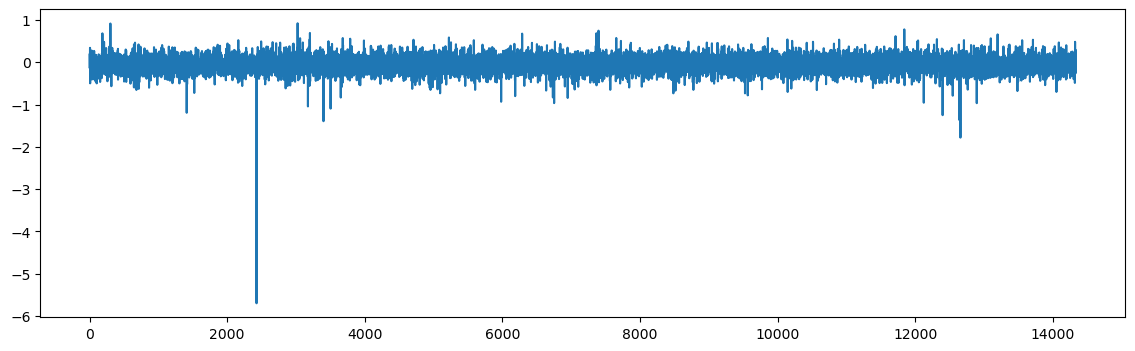

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(gate_baseline)
plt.show()

## Step 2 — Intervention: block attention from query pos 1 to key pos 0, layer `L`

We register a `forward_pre_hook` on `model.model.layers[L].self_attn` that
clones the additive `attention_mask` kwarg and sets the `(query_pos, key_pos)`
entry to the dtype's minimum value before the module runs. Cloning is
important — the same mask tensor object is reused across layers internally,
so mutating in place would corrupt every other layer's mask too.

In [8]:
def make_block_hook(query_pos, key_pos, dtype):
    fill_value = torch.finfo(dtype).min

    def hook(module, args, kwargs):
        attention_mask = kwargs.get('attention_mask', None)
        assert attention_mask is not None, (
            "attention_mask kwarg not found on self_attn — check transformers version"
        )
        attention_mask = attention_mask.clone()
        attention_mask[:, :, query_pos, key_pos] = fill_value
        kwargs['attention_mask'] = attention_mask
        return args, kwargs

    return hook

block_hook = make_block_hook(QUERY_POS, KEY_POS_TO_BLOCK, dtype=DTYPE)
target_module = model.model.layers[L].self_attn

gate_intervention, attn_intervention = capture_gate_vector(
    model, input_ids, extra_fwd_pre_hooks=[(target_module, block_hook)]
)

print("intervention attn pattern at layer L, query pos", QUERY_POS, "(per head, keys 0..QUERY_POS):")
print(attn_intervention[:, :QUERY_POS + 1])
print("\n-> expect ~0 in the key-0 column and ~1 in the key-1 column, for every head")
print("\ngate_intervention[neuron 2427] =", gate_intervention[NEURON_IDX])

intervention attn pattern at layer L, query pos 1 (per head, keys 0..QUERY_POS):
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

-> expect ~0 in the key-0 column and ~1 in the key-1 column, for every head

gate_intervention[neuron 2427] = 1.8712828


## Step 3 — Plot: gate vector at token position 1, baseline vs. intervention

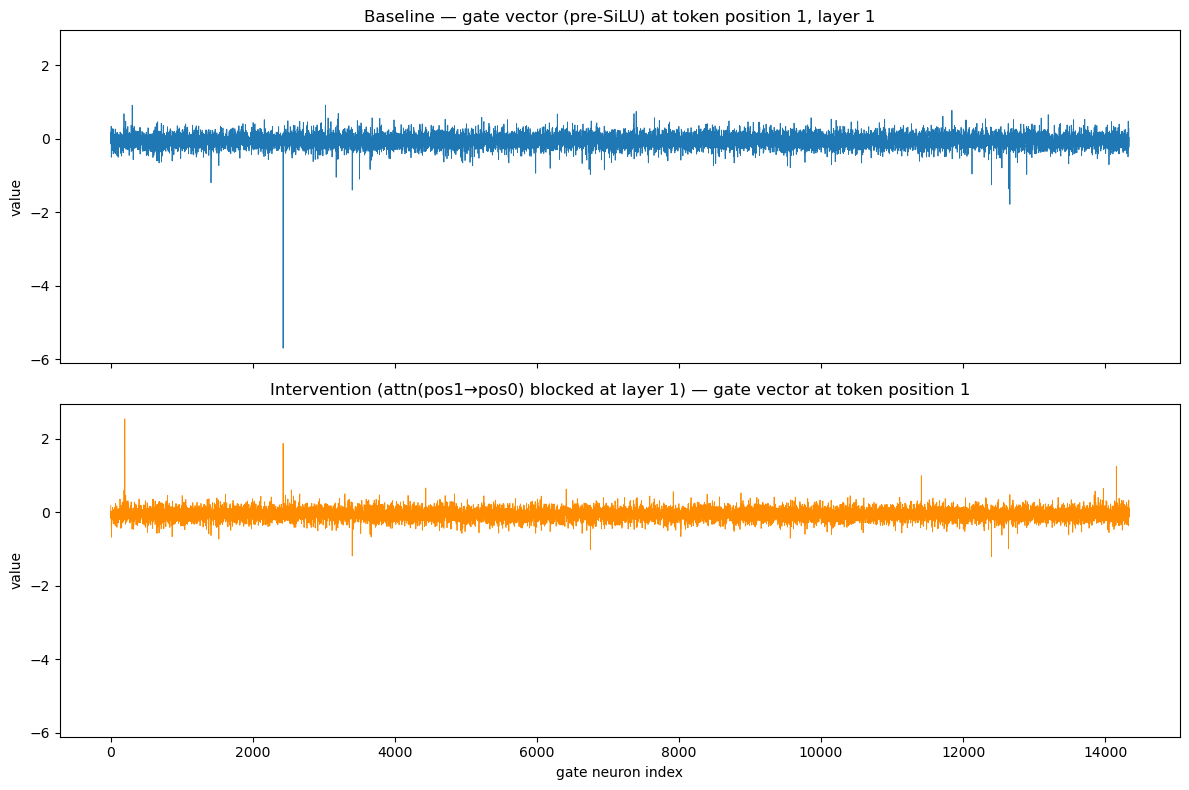


neuron 2427: baseline = -5.700  intervention = 1.871
sign flip present in baseline vs. layer-0 pos-0 pattern? compare against your MA reference values.
sign changed after intervention: True


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

axes[0].plot(gate_baseline, linewidth=0.6)
# axes[0].axvline(NEURON_IDX, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title(f"Baseline — gate vector (pre-SiLU) at token position {QUERY_POS}, layer {L}")
axes[0].set_ylabel("value")

axes[1].plot(gate_intervention, linewidth=0.6, color='darkorange')
# axes[1].axvline(NEURON_IDX, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set_title(
    f"Intervention (attn(pos1→pos0) blocked at layer {L}) — gate vector at token position {QUERY_POS}"
)
axes[1].set_xlabel("gate neuron index")
axes[1].set_ylabel("value")

plt.tight_layout()

import os
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "gate_vector_layer2_attn_ablation_pos1.png"), dpi=150)
plt.show()

print(f"\nneuron {NEURON_IDX}: baseline = {gate_baseline[NEURON_IDX]:.3f}  "
      f"intervention = {gate_intervention[NEURON_IDX]:.3f}")
print(f"sign flip present in baseline vs. layer-0 pos-0 pattern? compare against your MA reference values.")
print(f"sign changed after intervention: {np.sign(gate_baseline[NEURON_IDX]) != np.sign(gate_intervention[NEURON_IDX])}")

## Interpretation

- **If `gate_intervention[2427]` flips sign back toward positive (or moves substantially toward 0)**
  relative to `gate_baseline[2427]`: layer-2 self-attention (specifically the contribution routed
  from position 0) is causally responsible for suppressing the gate at position 1 — supports
  Dr. Liu's primary hypothesis. Next step: repeat this notebook with `L=1` to test whether layer-1
  attention *also* contributes, or whether layer-2 alone fully explains it.

- **If the sign is unchanged**: layer-2 self-attention is not the cause. Re-run with `L=1`
  (self-attention in the previous layer) before considering embedding-level (H1) explanations.
